In [ ]:
# Multidimensional Diversity Index (MDDI) Prototype
# This notebook analyzes a generated CSV for physical-disability service coverage gaps.
# Outputs: geographic zoning, taxonomy distribution, completeness viability, QEM recommendations.

In [1]:
import re
from pathlib import Path
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional dependency for zero-shot classification
try:
    from transformers import pipeline
    HAS_TRANSFORMERS = True
except Exception:
    pipeline = None
    HAS_TRANSFORMERS = False
    print("transformers not available. Falling back to keyword taxonomy classifier.")

pd.set_option("display.max_colwidth", 120)

In [8]:
# 1) Input CSV path
CSV_PATH = Path("dataset_employment_3.csv")

if not CSV_PATH.exists():
    print(f"CSV not found: {CSV_PATH}")
else:
    print(f"Using CSV: {CSV_PATH}")

Using CSV: dataset_employment_3.csv


In [3]:
# 2) Geographic zoning dictionaries from Ontario coordinates JSON
COORDS_JSON_PATH = Path("/home/k3v1n/projects/Automated-Research-System/test/extraction_test/ontario_city_coordinates.json")

if not COORDS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing coordinates JSON: {COORDS_JSON_PATH}")

ontario_city_coordinates = pd.read_json(COORDS_JSON_PATH).to_dict()

GTA_CITIES = {
    "toronto", "mississauga", "brampton", "markham", "vaughan", "richmond hill",
    "pickering", "ajax", "whitby", "oshawa", "oakville", "milton", "scarborough",
    "north york", "etobicoke", "east york", "newmarket", "aurora", "georgetown", "stouffville",
    "brooklin", "don mills", "sharon"
}

def _region_from_coords(city: str, lat: float, lon: float) -> str:
    city_norm = city.strip().lower()

    # Explicit GTA override for better precision around dense metro areas.
    if city_norm in GTA_CITIES:
        return "Greater Toronto Area"

    # Coordinate-based zoning for the rest of Ontario.
    if lat >= 46.5 or lon <= -84.0:
        return "Northern Ontario"
    if lon <= -77.2 and lat >= 43.3:
        return "Eastern Ontario"
    if lon <= -80.9 and lat <= 43.9:
        return "Southwestern Ontario"
    if -80.9 < lon <= -79.1 and 43.8 <= lat <= 45.5:
        return "Central Ontario"
    return "Western GTA Periphery"

ONTARIO_REGIONS: Dict[str, List[str]] = {
    "Greater Toronto Area": [],
    "Northern Ontario": [],
    "Eastern Ontario": [],
    "Southwestern Ontario": [],
    "Central Ontario": [],
    "Western GTA Periphery": [],
}

for city, coords in ontario_city_coordinates.items():
    lat = coords.get("lat")
    lon = coords.get("lon")
    if pd.isna(lat) or pd.isna(lon):
        continue
    region = _region_from_coords(str(city), float(lat), float(lon))
    ONTARIO_REGIONS[region].append(str(city))

# Keep lists stable and deduplicated
for region_name in ONTARIO_REGIONS:
    ONTARIO_REGIONS[region_name] = sorted(set(ONTARIO_REGIONS[region_name]))

CITY_TO_REGION = {
    city.lower(): region
    for region, cities in ONTARIO_REGIONS.items()
    for city in cities
}

def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip().lower()

def infer_region(city: str, address: str) -> str:
    city_norm = normalize_text(city)
    if city_norm in CITY_TO_REGION:
        return CITY_TO_REGION[city_norm]

    address_norm = normalize_text(address)
    for known_city, region in CITY_TO_REGION.items():
        if known_city in address_norm:
            return region
    return "Unmapped/Unknown"

print("Built ONTARIO_REGIONS from coordinates JSON.")
for region_name, cities in ONTARIO_REGIONS.items():
    print(f"- {region_name}: {len(cities)} cities")

Built ONTARIO_REGIONS from coordinates JSON.
- Greater Toronto Area: 19 cities
- Northern Ontario: 36 cities
- Eastern Ontario: 60 cities
- Southwestern Ontario: 15 cities
- Central Ontario: 0 cities
- Western GTA Periphery: 31 cities


In [4]:
# 3) Service taxonomy configuration for physical disabilities
PHYSICAL_DISABILITY_TAXONOMY = [
    "Mobility Aids and Assistive Devices",
    "Accessible Transportation",
    "Personal Support and Attendant Care",
    "Occupational Therapy and Rehabilitation",
    "Physiotherapy",
    "Housing and Accessibility Modifications",
    "Employment and Vocational Supports",
    "Income and Disability Benefits",
    "Legal Advocacy and Rights",
    "Independent Living Supports",
    "Education and School Accommodations",
    "Family and Caregiver Supports",
    "Mental Health Supports for Physical Disability",
    "Community Inclusion and Recreation",
    "Youth Services",
    "Crisis Intervention"
]

TAXONOMY_KEYWORDS = {
    "Mobility Aids and Assistive Devices": ["wheelchair", "walker", "assistive", "prosthetic", "orthotic", "device"],
    "Accessible Transportation": ["transport", "transit", "paratransit", "wheel-trans", "mobility ride"],
    "Personal Support and Attendant Care": ["attendant", "personal support", "home care", "psw"],
    "Occupational Therapy and Rehabilitation": ["occupational therapy", "ot", "rehabilitation"],
    "Physiotherapy": ["physiotherapy", "physio", "physical therapy"],
    "Housing and Accessibility Modifications": ["housing", "accessible home", "ramp", "modification", "barrier-free"],
    "Employment and Vocational Supports": ["employment", "job", "vocational", "workplace accommodation"],
    "Income and Disability Benefits": ["odsp", "benefit", "income support", "financial assistance"],
    "Legal Advocacy and Rights": ["legal", "advocacy", "rights", "human rights", "tribunal"],
    "Independent Living Supports": ["independent living", "peer support", "self-management"],
    "Education and School Accommodations": ["school", "education", "iep", "accommodation", "student"],
    "Family and Caregiver Supports": ["caregiver", "family support", "respite"],
    "Mental Health Supports for Physical Disability": ["mental health", "counseling", "therapy", "wellbeing"],
    "Community Inclusion and Recreation": ["recreation", "inclusion", "community program", "social participation"],
    "Youth Services": ["youth", "teen", "adolescent", "pediatric", "high school"],
    "Crisis Intervention": ["crisis", "emergency", "urgent", "detox", "helpline"]
}

def build_zero_shot_classifier():
    if not HAS_TRANSFORMERS:
        return None
    return pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=0
    )

def classify_taxonomy(text: str, classifier=None) -> str:
    text = "" if pd.isna(text) else str(text).strip()
    if not text:
        return "Unclassified"

    if classifier is not None:
        result = classifier(
            text,
            candidate_labels=PHYSICAL_DISABILITY_TAXONOMY,
            multi_label=False
        )
        return result["labels"][0]

    low = text.lower()
    for label, words in TAXONOMY_KEYWORDS.items():
        if any(w in low for w in words):
            return label
    return "Unclassified"

In [5]:
# 4) Core MDDI computations
def add_mddi_columns(df: pd.DataFrame, classifier=None) -> pd.DataFrame:
    out = df.copy()

    city_col = "city" if "city" in out.columns else None
    address_col = "address" if "address" in out.columns else None
    desc_col = "description" if "description" in out.columns else None
    phone_col = "phone" if "phone" in out.columns else None
    website_col = "website" if "website" in out.columns else None

    out["macro_region"] = out.apply(
        lambda r: infer_region(
            r[city_col] if city_col else "",
            r[address_col] if address_col else ""
        ),
        axis=1
    )

    if desc_col:
        out["service_taxonomy"] = out[desc_col].apply(lambda x: classify_taxonomy(x, classifier=classifier))
    else:
        out["service_taxonomy"] = "Unclassified"

    has_phone = out[phone_col].fillna("").astype(str).str.strip().ne("") if phone_col else pd.Series(False, index=out.index)
    has_address = out[address_col].fillna("").astype(str).str.strip().ne("") if address_col else pd.Series(False, index=out.index)
    has_website = out[website_col].fillna("").astype(str).str.strip().ne("") if website_col else pd.Series(False, index=out.index)

    out["has_full_contact_info"] = has_phone & has_address
    out["missing_website"] = ~has_website
    out["missing_phone"] = ~has_phone

    out["completeness_category"] = np.select(
        [
            out["has_full_contact_info"],
            out["missing_website"],
            out["missing_phone"]
        ],
        [
            "Full Contact Info",
            "Missing Website",
            "Missing Phone"
        ],
        default="Other"
    )

    return out

def summarize_mddi(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    total = max(len(df), 1)

    geography_counts = (
        df.groupby("macro_region", dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    geography_counts["share"] = geography_counts["count"] / total

    taxonomy_counts = (
        df.groupby("service_taxonomy", dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    taxonomy_counts["share"] = taxonomy_counts["count"] / total

    completeness_counts = (
        df.groupby("completeness_category", dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    completeness_counts["share"] = completeness_counts["count"] / total

    return {
        "geography": geography_counts,
        "taxonomy": taxonomy_counts,
        "completeness": completeness_counts
    }

In [6]:
# 5) Visualizations
def plot_geography(geo_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(geo_df["macro_region"], geo_df["count"])
    ax.set_title("Entity Count by Ontario Macro-Region")
    ax.set_xlabel("Macro-Region")
    ax.set_ylabel("Entity Count")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

def plot_taxonomy(tax_df: pd.DataFrame, top_n: int = 12):
    show_df = tax_df.head(top_n).sort_values("count", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(show_df["service_taxonomy"], show_df["count"])
    ax.set_title(f"Top {top_n} Service Taxonomy Categories")
    ax.set_xlabel("Entity Count")
    ax.set_ylabel("Category")
    plt.tight_layout()
    plt.show()

def plot_completeness_donut(comp_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        comp_df["count"],
        labels=comp_df["completeness_category"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.45}
    )
    ax.set_title("Data Completeness & Scraping Viability")
    plt.tight_layout()
    plt.show()

In [7]:
# 6) QEM mapping dictionary and command generator
qem_mappings = {
    "regions": {
        "Northern Ontario": ["Sudbury", "Thunder Bay", "Sault Ste. Marie", "Timmins", "Kenora", "North Bay"],
        "Eastern Ontario": ["Ottawa", "Cornwall", "Kingston", "Belleville", "Pembroke"],
        "Southwestern Ontario": ["London", "Windsor", "Chatham", "Sarnia", "Woodstock"],
        "Greater Toronto Area": ["Toronto", "Mississauga", "Brampton", "Markham", "Vaughan"],
        "Central Ontario": ["Barrie", "Orillia", "Peterborough", "Kawartha Lakes", "Parry Sound"]
    },
    "taxonomies": {
        "Youth Services": ["Youth", "Teen", "Adolescent", "Pediatric", "High School"],
        "Crisis Intervention": ["Emergency", "Crisis", "Urgent Care", "Helpline", "Rapid Response"],
        "Accessible Transportation": ["Accessible Transit", "Paratransit", "Mobility Transport", "Wheel-Trans"],
        "Housing and Accessibility Modifications": ["Accessible Housing", "Home Modification", "Ramp", "Barrier-Free"],
        "Personal Support and Attendant Care": ["Attendant", "Personal Support", "Home Care", "PSW"]
    },
    "sources": {
        "Missing Website": ["directory", "filetype:pdf", "filetype:csv", "open data", "community guide"]
    }
}

def generate_next_qem_command(missing_region: str, missing_taxonomy: str, strategy: str = "Deep Dive") -> str:
    scopes = qem_mappings["regions"].get(missing_region, [missing_region])
    entities = qem_mappings["taxonomies"].get(missing_taxonomy, [missing_taxonomy])
    recommendation = (
        f"DATA GAP DETECTED: {missing_taxonomy} in {missing_region}.\n\n"
        f"RECOMMENDED SYSTEM ACTION:\n"
        f"Initialize Node 1 (QEM) with the following parameters:\n"
        f"- [Entities]: {', '.join(entities)}\n"
        f"- [Scopes]: {', '.join(scopes)}\n"
        f"- [Strategy]: The '{strategy}' strategy\n\n"
        f"Execute Crawl4AI on generated URLs."
    )
    return recommendation

def generate_source_qem_command(gap_label: str = "Missing Website", strategy: str = "Artifact Hunter") -> str:
    source_terms = qem_mappings["sources"].get(gap_label, ["directory", "filetype:pdf"])
    return (
        f"DATA GAP DETECTED: {gap_label}.\n\n"
        f"RECOMMENDED SYSTEM ACTION:\n"
        f"Initialize Node 1 (QEM) with:\n"
        f"- [Source]: {', '.join(source_terms)}\n"
        f"- [Strategy]: The '{strategy}' (Entity + Scope + Source)\n\n"
        f"Execute Crawl4AI on generated URLs."
    )

Rows: 255
Columns: ['address', 'city', 'name', 'phone', 'query_technique', 'source_query', 'source_url']


Device set to use cuda:0



Geography Insight


,macro_region,count,share
1,Greater Toronto Area,136,0.533333
4,Western GTA Periphery,47,0.184314
3,Unmapped/Unknown,40,0.156863
2,Southwestern Ontario,21,0.082353
0,Eastern Ontario,11,0.043137



Taxonomy Insight


,service_taxonomy,count,share
0,Unclassified,255,1.0



Completeness Insight


,completeness_category,count,share
0,Full Contact Info,255,1.0


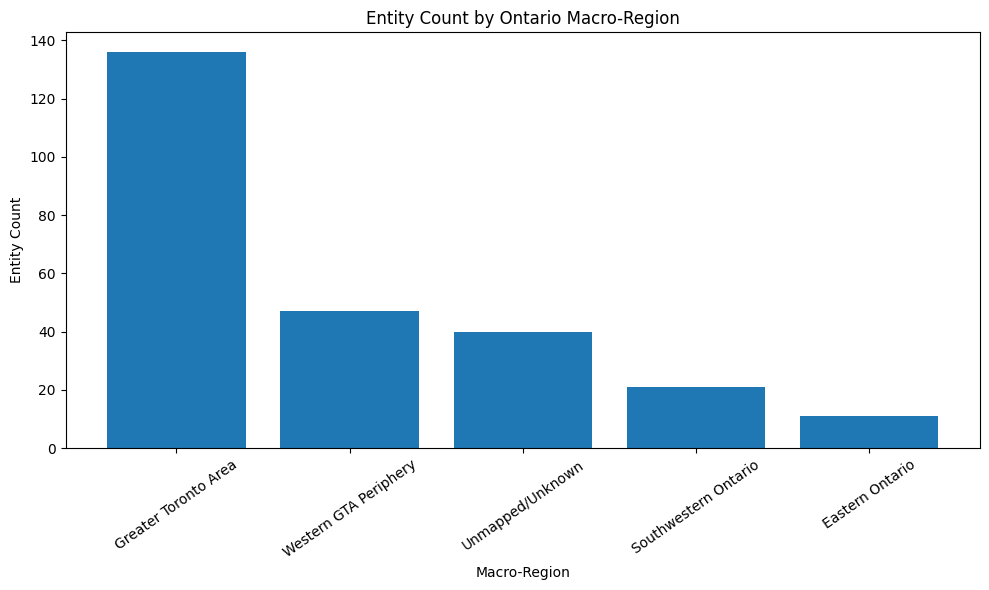

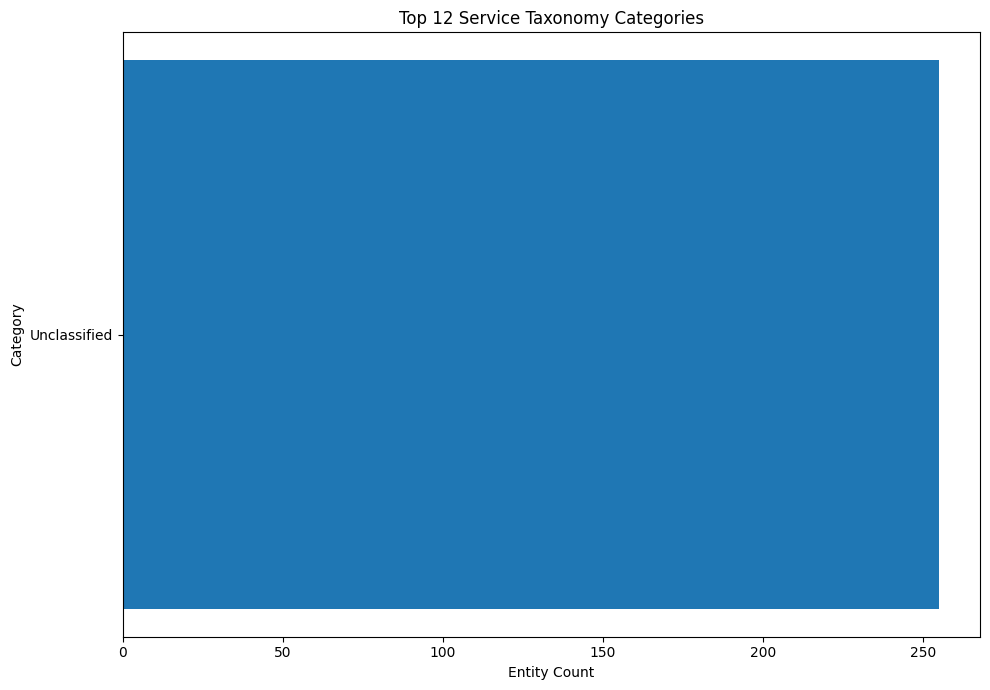

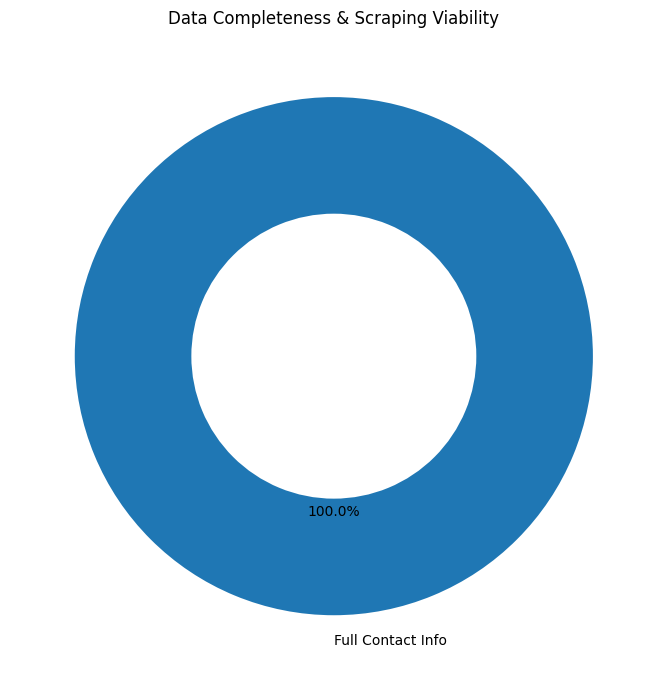


--- Recommended QEM Actions ---

Recommendation 1
DATA GAP DETECTED: Youth Services in Southwestern Ontario.

RECOMMENDED SYSTEM ACTION:
Initialize Node 1 (QEM) with the following parameters:
- [Entities]: Youth, Teen, Adolescent, Pediatric, High School
- [Scopes]: London, Windsor, Chatham, Sarnia, Woodstock
- [Strategy]: The 'Broad Net' strategy

Execute Crawl4AI on generated URLs.

Recommendation 2
DATA GAP DETECTED: Youth Services in Eastern Ontario.

RECOMMENDED SYSTEM ACTION:
Initialize Node 1 (QEM) with the following parameters:
- [Entities]: Youth, Teen, Adolescent, Pediatric, High School
- [Scopes]: Ottawa, Cornwall, Kingston, Belleville, Pembroke
- [Strategy]: The 'Broad Net' strategy

Execute Crawl4AI on generated URLs.

Saved enriched output: /home/k3v1n/projects/Automated-Research-System/test/MDDI/mddi_enriched_output.csv


In [9]:
# 7) Run the full MDDI analysis and generate recommendations
REGION_GAP_THRESHOLD = 0.10
TAXONOMY_GAP_THRESHOLD = 0.05

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV does not exist: {CSV_PATH}")

df_raw = pd.read_csv(CSV_PATH)
print("Rows:", len(df_raw))
print("Columns:", list(df_raw.columns))

classifier = build_zero_shot_classifier()
df_mddi = add_mddi_columns(df_raw, classifier=classifier)
insights = summarize_mddi(df_mddi)

print("\nGeography Insight")
display(insights["geography"])
print("\nTaxonomy Insight")
display(insights["taxonomy"].head(20))
print("\nCompleteness Insight")
display(insights["completeness"])

plot_geography(insights["geography"])
plot_taxonomy(insights["taxonomy"], top_n=12)
plot_completeness_donut(insights["completeness"])

print("\n--- Recommended QEM Actions ---")
recommendations = []

# Missing geography -> Scope bucket
geo_gaps = insights["geography"][insights["geography"]["share"] < REGION_GAP_THRESHOLD]
for _, row in geo_gaps.iterrows():
    region_name = row["macro_region"]
    if region_name in qem_mappings["regions"]:
        recommendations.append(generate_next_qem_command(region_name, "Youth Services", strategy="Broad Net"))

# Missing taxonomy -> Entity/Attribute bucket
tax_gaps = insights["taxonomy"][insights["taxonomy"]["share"] < TAXONOMY_GAP_THRESHOLD]
for _, row in tax_gaps.head(5).iterrows():
    label = row["service_taxonomy"]
    if label in qem_mappings["taxonomies"]:
        recommendations.append(generate_next_qem_command("Northern Ontario", label, strategy="Deep Dive"))

# Missing websites -> Source bucket
missing_web = insights["completeness"].query("completeness_category == 'Missing Website'")
if not missing_web.empty and float(missing_web.iloc[0]["share"]) > 0.25:
    recommendations.append(generate_source_qem_command("Missing Website", strategy="Artifact Hunter"))

if not recommendations:
    print("No major gaps detected at current thresholds.")
else:
    for i, rec in enumerate(recommendations, 1):
        print(f"\nRecommendation {i}\n{rec}")

OUTPUT_PATH = Path("/home/k3v1n/projects/Automated-Research-System/test/MDDI/mddi_enriched_output.csv")
df_mddi.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved enriched output: {OUTPUT_PATH}")